In [ ]:
# Imports & Setup 
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')


# MLP architecture 
class MLP(nn.Module):
    def __init__(self, input_dim, hidden=[128, 64, 32], num_classes=5, dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

# Load data
train_df = pd.read_csv('../data/ocpp_app_layer/Combined/Train.csv')
test_df  = pd.read_csv('../data/ocpp_app_layer/Combined/Test.csv')

label_col = 'label'
feature_cols = [c for c in train_df.columns 
                if c != label_col and train_df[c].dtype in ['float64', 'int64', 'float32', 'int32']]
print(f"Using {len(feature_cols)} numeric features")

le = LabelEncoder()
y_train = le.fit_transform(train_df[label_col])
y_test  = le.transform(test_df[label_col])

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols].values)
X_test  = scaler.transform(test_df[feature_cols].values)

# Train fresh model
def train_model(X_tr, y_tr, input_dim, epochs=50, patience=10):
    torch.manual_seed(42)
    m = MLP(input_dim=input_dim)
    optimizer = torch.optim.Adam(m.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    X_t = torch.tensor(X_tr, dtype=torch.float32)
    y_t = torch.tensor(y_tr, dtype=torch.long)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=32, shuffle=True)
    best_loss, wait, best_state = float('inf'), 0, None
    m.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(m(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if epoch_loss < best_loss:
            best_loss, wait = epoch_loss, 0
            best_state = {k: v.clone() for k, v in m.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break
    m.load_state_dict(best_state)
    m.eval()
    return m

print("Training model...")
model = train_model(X_train, y_train, input_dim=X_train.shape[1])

# Predict function
def predict(X_np):
    with torch.no_grad():
        logits = model(torch.tensor(X_np, dtype=torch.float32))
        probs  = torch.softmax(logits, dim=1).numpy()
        preds  = np.argmax(probs, axis=1)
    return preds, probs

# Save model for reuse in later cells
torch.save(model.state_dict(), '../outputs/mlp_final_v2.pt')

print("Done.")
print(f"Input features : {X_train.shape[1]}")
print(f"Train samples  : {X_train.shape[0]}")
print(f"Test samples   : {X_test.shape[0]}")
print(f"Classes        : {le.classes_}")

Using 51 numeric features
Training model...
  Early stopping at epoch 27
Done.
Input features : 51
Train samples  : 3020
Test samples   : 1295
Classes        : ['cyberattack_ocpp16_doc_idtag'
 'cyberattack_ocpp16_dos_flooding_heartbeat'
 'cyberattack_ocpp16_fdi_chargingprofile'
 'cyberattack_ocpp16_unauthorized_access' 'normal']


In [ ]:
preds_clean, probs_clean = predict(X_test)
acc_clean = accuracy_score(y_test, preds_clean)
f1_clean  = f1_score(y_test, preds_clean, average='macro')

print(f"Clean Accuracy : {acc_clean:.4f}")
print(f"Clean Macro F1 : {f1_clean:.4f}")

Clean Accuracy : 0.9992
Clean Macro F1 : 0.9992


In [ ]:
# Stress Test 1 — Gaussian Noise
results = []

for sigma in [0.1, 0.5, 1.0, 2.0]:
    np.random.seed(42)
    X_noisy = X_test + np.random.normal(0, sigma, X_test.shape)
    preds_n, _ = predict(X_noisy)
    acc = accuracy_score(y_test, preds_n)
    f1  = f1_score(y_test, preds_n, average='macro')
    results.append({'Test': f'Gaussian Noise σ={sigma}', 'Accuracy': acc, 'Macro F1': f1})
    print(f"σ={sigma:4.1f}  →  Acc={acc:.4f}  F1={f1:.4f}")

noise_results = pd.DataFrame(results)

σ= 0.1  →  Acc=0.9992  F1=0.9992
σ= 0.5  →  Acc=0.9938  F1=0.9938
σ= 1.0  →  Acc=0.9436  F1=0.9436
σ= 2.0  →  Acc=0.7699  F1=0.7707


In [ ]:
# Stress Test 2 — Feature Masking
mask_results = []

for pct in [0.10, 0.25, 0.50]:
    np.random.seed(42)
    X_masked = X_test.copy()
    n_mask = int(pct * X_test.shape[1])
    mask_cols = np.random.choice(X_test.shape[1], n_mask, replace=False)
    X_masked[:, mask_cols] = 0.0   # zero-fill = mean imputation after scaling
    preds_m, _ = predict(X_masked)
    acc = accuracy_score(y_test, preds_m)
    f1  = f1_score(y_test, preds_m, average='macro')
    mask_results.append({'Test': f'Feature Masking {int(pct*100)}%', 'Accuracy': acc, 'Macro F1': f1})
    print(f"Mask {int(pct*100):3d}% features  →  Acc={acc:.4f}  F1={f1:.4f}")

mask_df = pd.DataFrame(mask_results)

Mask  10% features  →  Acc=0.9961  F1=0.9961
Mask  25% features  →  Acc=0.9985  F1=0.9985
Mask  50% features  →  Acc=0.9931  F1=0.9931


In [ ]:
# Stress Test 3 — OOD Samples
np.random.seed(42)

# OOD: random uniform samples far outside the training distribution
X_ood = np.random.uniform(low=-10, high=10, size=(500, X_test.shape[1]))
preds_ood, probs_ood = predict(X_ood)

# For OOD we measure confidence (we have no true labels)
max_conf = probs_ood.max(axis=1)
print(f"OOD samples: 500")
print(f"Mean max confidence : {max_conf.mean():.4f}")
print(f"% predictions with confidence > 0.9 : {(max_conf > 0.9).mean()*100:.1f}%")
print(f"% predictions with confidence > 0.5 : {(max_conf > 0.5).mean()*100:.1f}%")
print("\nPrediction class distribution on OOD data:")
unique, counts = np.unique(preds_ood, return_counts=True)
for cls, cnt in zip(le.classes_[unique], counts):
    print(f"  {cls}: {cnt} ({cnt/500*100:.1f}%)")

OOD samples: 500
Mean max confidence : 0.9755
% predictions with confidence > 0.9 : 92.4%
% predictions with confidence > 0.5 : 100.0%

Prediction class distribution on OOD data:
  cyberattack_ocpp16_doc_idtag: 96 (19.2%)
  cyberattack_ocpp16_dos_flooding_heartbeat: 95 (19.0%)
  cyberattack_ocpp16_fdi_chargingprofile: 98 (19.6%)
  cyberattack_ocpp16_unauthorized_access: 23 (4.6%)
  normal: 188 (37.6%)


In [ ]:
# Stress Test 4 — Class Rarity Scenario
# Simulate a scenario where one attack class is severely underrepresented
# in a new deployment batch (only 5 samples of that class visible)

rarity_results = []
class_names = le.classes_

for target_class_idx in range(5):
    # all samples of other classes + only 5 of target
    mask_other = y_test != target_class_idx
    mask_target = np.where(y_test == target_class_idx)[0][:5]
    
    idx_other = np.where(mask_other)[0]
    combined = np.concatenate([idx_other, mask_target])
    
    X_rare = X_test[combined]
    y_rare = y_test[combined]
    
    preds_r, _ = predict(X_rare)
    
    # Per-class recall for the rare class
    from sklearn.metrics import recall_score
    rec = recall_score(y_rare, preds_r, labels=[target_class_idx], average=None)
    f1_macro = f1_score(y_rare, preds_r, average='macro')
    
    rarity_results.append({
        'Rare Class': class_names[target_class_idx],
        'Rare Class Recall': rec[0] if len(rec) > 0 else 0.0,
        'Macro F1': f1_macro
    })
    print(f"Rare class: {class_names[target_class_idx]:40s}  Recall={rec[0] if len(rec)>0 else 0:.4f}  MacroF1={f1_macro:.4f}")

rarity_df = pd.DataFrame(rarity_results)

Rare class: cyberattack_ocpp16_doc_idtag              Recall=1.0000  MacroF1=0.9814
Rare class: cyberattack_ocpp16_dos_flooding_heartbeat  Recall=1.0000  MacroF1=0.9992
Rare class: cyberattack_ocpp16_fdi_chargingprofile    Recall=1.0000  MacroF1=0.9992
Rare class: cyberattack_ocpp16_unauthorized_access    Recall=1.0000  MacroF1=0.9992
Rare class: normal                                    Recall=1.0000  MacroF1=1.0000


In [ ]:
# Full Stress Test Summary Table
import pandas as pd

baseline_row = pd.DataFrame([{
    'Test': 'Clean Baseline', 
    'Accuracy': acc_clean, 
    'Macro F1': f1_clean
}])

summary = pd.concat([baseline_row, noise_results, mask_df], ignore_index=True)
summary['Accuracy'] = summary['Accuracy'].map('{:.4f}'.format)
summary['Macro F1'] = summary['Macro F1'].map('{:.4f}'.format)

print("=" * 55)
print("STRESS TEST SUMMARY")
print("=" * 55)
print(summary.to_string(index=False))
print("=" * 55)

STRESS TEST SUMMARY
                Test Accuracy Macro F1
      Clean Baseline   0.9992   0.9992
Gaussian Noise σ=0.1   0.9992   0.9992
Gaussian Noise σ=0.5   0.9938   0.9938
Gaussian Noise σ=1.0   0.9436   0.9436
Gaussian Noise σ=2.0   0.7699   0.7707
 Feature Masking 10%   0.9961   0.9961
 Feature Masking 25%   0.9985   0.9985
 Feature Masking 50%   0.9931   0.9931


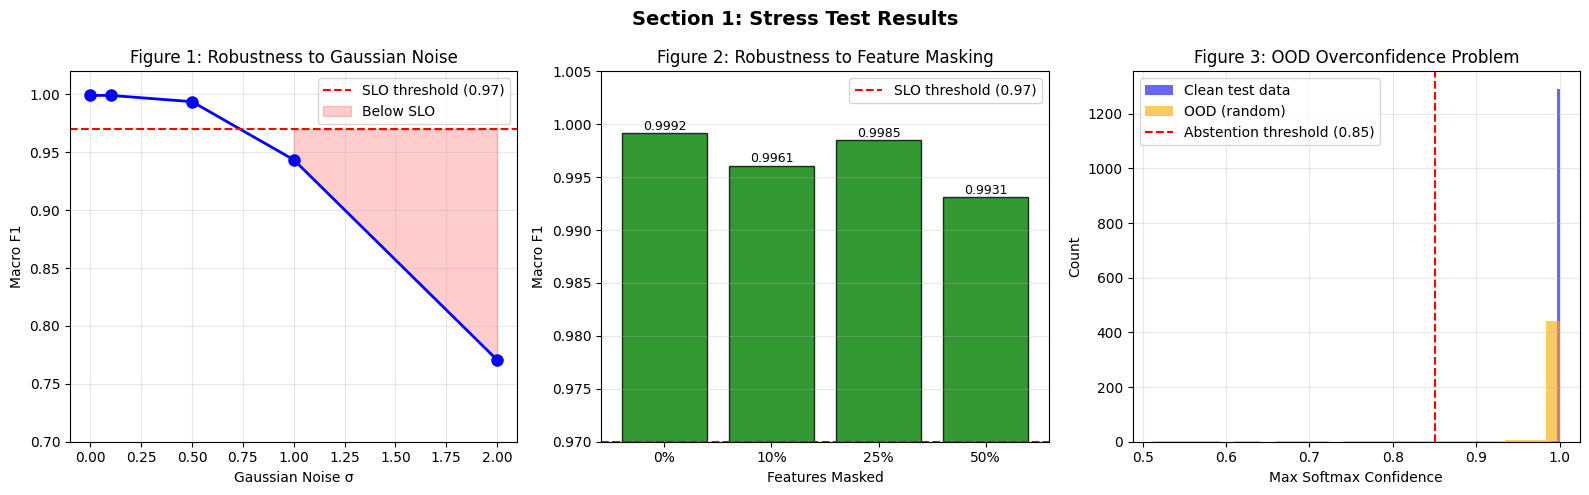

Figure saved to outputs/figures/section1_stress_tests.png


In [ ]:
# Visualizations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Section 1: Stress Test Results', fontsize=14, fontweight='bold')

# Plot 1: Noise robustness curve
sigmas = [0, 0.1, 0.5, 1.0, 2.0]
f1_noise = [0.9992, 0.9992, 0.9938, 0.9436, 0.7707]
axes[0].plot(sigmas, f1_noise, 'bo-', linewidth=2, markersize=8)
axes[0].axhline(y=0.97, color='red', linestyle='--', label='SLO threshold (0.97)')
axes[0].fill_between(sigmas, f1_noise, 0.97, where=[f < 0.97 for f in f1_noise],
                     alpha=0.2, color='red', label='Below SLO')
axes[0].set_xlabel('Gaussian Noise σ')
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Figure 1: Robustness to Gaussian Noise')
axes[0].set_ylim(0.7, 1.02)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Feature masking robustness
mask_pct = [0, 10, 25, 50]
f1_mask  = [0.9992, 0.9961, 0.9985, 0.9931]
axes[1].bar([str(p)+'%' for p in mask_pct], f1_mask, 
            color=['green' if f >= 0.97 else 'red' for f in f1_mask],
            edgecolor='black', alpha=0.8)
axes[1].axhline(y=0.97, color='red', linestyle='--', label='SLO threshold (0.97)')
axes[1].set_xlabel('Features Masked')
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Figure 2: Robustness to Feature Masking')
axes[1].set_ylim(0.97, 1.005)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(f1_mask):
    axes[1].text(i, v + 0.0003, f'{v:.4f}', ha='center', fontsize=9)

# Plot 3: OOD confidence histogram
np.random.seed(42)
X_ood_plot = np.random.uniform(low=-10, high=10, size=(500, X_test.shape[1]))
_, probs_ood_plot = predict(X_ood_plot)
_, probs_clean_plot = predict(X_test)
max_conf_ood   = probs_ood_plot.max(axis=1)
max_conf_clean = probs_clean_plot.max(axis=1)

axes[2].hist(max_conf_clean, bins=30, alpha=0.6, color='blue', label='Clean test data')
axes[2].hist(max_conf_ood,   bins=30, alpha=0.6, color='orange', label='OOD (random)')
axes[2].axvline(x=0.85, color='red', linestyle='--', label='Abstention threshold (0.85)')
axes[2].set_xlabel('Max Softmax Confidence')
axes[2].set_ylabel('Count')
axes[2].set_title('Figure 3: OOD Overconfidence Problem')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/section1_stress_tests.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to outputs/figures/section1_stress_tests.png")

In [ ]:
# Data-level: Jittering Augmentation and Retrain
from torch.utils.data import DataLoader, TensorDataset

def train_model_with_jitter(X_tr, y_tr, input_dim, jitter_std=0.05, epochs=50, patience=10):
    torch.manual_seed(42)
    m = MLP(input_dim=input_dim)
    optimizer = torch.optim.Adam(m.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    X_t = torch.tensor(X_tr, dtype=torch.float32)
    y_t = torch.tensor(y_tr, dtype=torch.long)
    
    best_loss, wait, best_state = float('inf'), 0, None
    m.train()
    for epoch in range(epochs):
        # Shuffle manually
        idx = torch.randperm(len(X_t))
        X_shuf, y_shuf = X_t[idx], y_t[idx]
        epoch_loss = 0
        for i in range(0, len(X_shuf), 32):
            xb = X_shuf[i:i+32]
            yb = y_shuf[i:i+32]
            # Add jitter noise during training
            xb = xb + torch.randn_like(xb) * jitter_std
            optimizer.zero_grad()
            loss = criterion(m(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if epoch_loss < best_loss:
            best_loss, wait = epoch_loss, 0
            best_state = {k: v.clone() for k, v in m.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break
    m.load_state_dict(best_state)
    m.eval()
    return m

print("Training jittered model (σ=0.05)...")
model_jitter = train_model_with_jitter(X_train, y_train, 
                                        input_dim=X_train.shape[1], 
                                        jitter_std=0.05)

# Compare baseline vs jittered on clean test set
preds_base,  probs_base   = predict(X_test)
preds_jitter, probs_jitter = (lambda m: (
    np.argmax(torch.softmax(m(torch.tensor(X_test, dtype=torch.float32)), dim=1).detach().numpy(), axis=1),
    torch.softmax(m(torch.tensor(X_test, dtype=torch.float32)), dim=1).detach().numpy()
))(model_jitter)

acc_base   = accuracy_score(y_test, preds_base)
acc_jitter = accuracy_score(y_test, preds_jitter)
f1_base    = f1_score(y_test, preds_base,   average='macro')
f1_jitter  = f1_score(y_test, preds_jitter, average='macro')

print(f"\nClean test — Baseline  : Acc={acc_base:.4f}  F1={f1_base:.4f}")
print(f"Clean test — Jittered  : Acc={acc_jitter:.4f}  F1={f1_jitter:.4f}")

# Save jittered model
torch.save(model_jitter.state_dict(), '../outputs/mlp_jittered.pt')
print("\nJittered model saved.")

Training jittered model (σ=0.05)...

Clean test — Baseline  : Acc=0.9992  F1=0.9992
Clean test — Jittered  : Acc=0.9992  F1=0.9992

Jittered model saved.


In [ ]:
# Inference-level — Temperature Scaling and Abstention
import torch.optim as optim

# Temperature Scaling
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)
    def forward(self, logits):
        return logits / self.temperature

# Get logits from baseline model on validation set
# Use 20% of train as val for calibration
from sklearn.model_selection import train_test_split
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

with torch.no_grad():
    val_logits = model(torch.tensor(X_val, dtype=torch.float32))
    val_labels = torch.tensor(y_val, dtype=torch.long)

# Fit temperature
scaler_T = TemperatureScaler()
optimizer_T = optim.LBFGS([scaler_T.temperature], lr=0.01, max_iter=50)
criterion_ce = nn.CrossEntropyLoss()

def eval_temp():
    optimizer_T.zero_grad()
    loss = criterion_ce(scaler_T(val_logits), val_labels)
    loss.backward()
    return loss

optimizer_T.step(eval_temp)
T = scaler_T.temperature.item()
print(f"Optimal temperature: T = {T:.4f}")

# Apply to test set
with torch.no_grad():
    test_logits = model(torch.tensor(X_test, dtype=torch.float32))
    scaled_probs = torch.softmax(scaler_T(test_logits), dim=1).numpy()
    raw_probs    = torch.softmax(test_logits, dim=1).numpy()

# Confidence Thresholding / Abstention
THRESHOLD = 0.85
preds_scaled = np.argmax(scaled_probs, axis=1)
max_conf_scaled = scaled_probs.max(axis=1)
max_conf_raw    = raw_probs.max(axis=1)

abstained = (max_conf_scaled < THRESHOLD).sum()
total     = len(preds_scaled)

print(f"\nConfidence Threshold   : {THRESHOLD}")
print(f"Abstained predictions  : {abstained} / {total} ({abstained/total*100:.1f}%)")
print(f"Accepted predictions   : {total - abstained} ({(total-abstained)/total*100:.1f}%)")

# Accuracy on accepted only
accepted_mask = max_conf_scaled >= THRESHOLD
acc_accepted  = accuracy_score(y_test[accepted_mask], preds_scaled[accepted_mask])
f1_accepted   = f1_score(y_test[accepted_mask], preds_scaled[accepted_mask], average='macro')
print(f"Accuracy on accepted   : {acc_accepted:.4f}")
print(f"Macro F1 on accepted   : {f1_accepted:.4f}")

Optimal temperature: T = 1.4993

Confidence Threshold   : 0.85
Abstained predictions  : 1 / 1295 (0.1%)
Accepted predictions   : 1294 (99.9%)
Accuracy on accepted   : 0.9992
Macro F1 on accepted   : 0.9992


In [ ]:
# FGSM Adversarial Evaluation
def fgsm_attack(model, X_np, y_np, epsilon):
    X_tensor = torch.tensor(X_np, dtype=torch.float32, requires_grad=True)
    y_tensor = torch.tensor(y_np, dtype=torch.long)
    
    model.eval()
    output = model(X_tensor)
    loss = nn.CrossEntropyLoss()(output, y_tensor)
    model.zero_grad()
    loss.backward()
    
    # Collect gradient sign and perturb
    perturbation = epsilon * X_tensor.grad.data.sign()
    X_adv = (X_tensor + perturbation).detach().numpy()
    return X_adv

epsilons = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3]
fgsm_results = []

print("FGSM Adversarial Evaluation")
print("=" * 60)
for eps in epsilons:
    if eps == 0.0:
        X_eval = X_test
    else:
        X_eval = fgsm_attack(model, X_test, y_test, eps)
    
    preds_adv, probs_adv = predict(X_eval)
    acc = accuracy_score(y_test, preds_adv)
    f1  = f1_score(y_test, preds_adv, average='macro')
    mean_conf = probs_adv.max(axis=1).mean()
    
    fgsm_results.append({
        'Epsilon': eps,
        'Accuracy': acc,
        'Macro F1': f1,
        'Mean Confidence': mean_conf
    })
    print(f"ε={eps:.2f}  →  Acc={acc:.4f}  F1={f1:.4f}  MeanConf={mean_conf:.4f}")

fgsm_df = pd.DataFrame(fgsm_results)

# test jittered model under FGSM
print("\nJittered Model under FGSM:")
print("=" * 60)
fgsm_jitter_results = []
for eps in epsilons:
    if eps == 0.0:
        X_eval = X_test
    else:
        X_eval = fgsm_attack(model_jitter, X_test, y_test, eps)
    with torch.no_grad():
        logits = model_jitter(torch.tensor(X_eval, dtype=torch.float32))
        probs  = torch.softmax(logits, dim=1).numpy()
        preds  = np.argmax(probs, axis=1)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='macro')
    fgsm_jitter_results.append({'Epsilon': eps, 'Accuracy': acc, 'Macro F1': f1})
    print(f"ε={eps:.2f}  →  Acc={acc:.4f}  F1={f1:.4f}")

fgsm_jitter_df = pd.DataFrame(fgsm_jitter_results)

FGSM Adversarial Evaluation
ε=0.00  →  Acc=0.9992  F1=0.9992  MeanConf=0.9999
ε=0.01  →  Acc=0.9992  F1=0.9992  MeanConf=0.9998
ε=0.05  →  Acc=0.9985  F1=0.9985  MeanConf=0.9997
ε=0.10  →  Acc=0.9977  F1=0.9977  MeanConf=0.9990
ε=0.20  →  Acc=0.9907  F1=0.9907  MeanConf=0.9957
ε=0.30  →  Acc=0.9583  F1=0.9572  MeanConf=0.9487

Jittered Model under FGSM:
ε=0.00  →  Acc=0.9992  F1=0.9992
ε=0.01  →  Acc=0.9985  F1=0.9985
ε=0.05  →  Acc=0.9985  F1=0.9985
ε=0.10  →  Acc=0.9961  F1=0.9961
ε=0.20  →  Acc=0.9853  F1=0.9853
ε=0.30  →  Acc=0.7737  F1=0.7104


Clean   — p50=0.0618ms  p90=0.0774ms
Adv(ε=0.1) — p50=0.0658ms  p90=0.3665ms


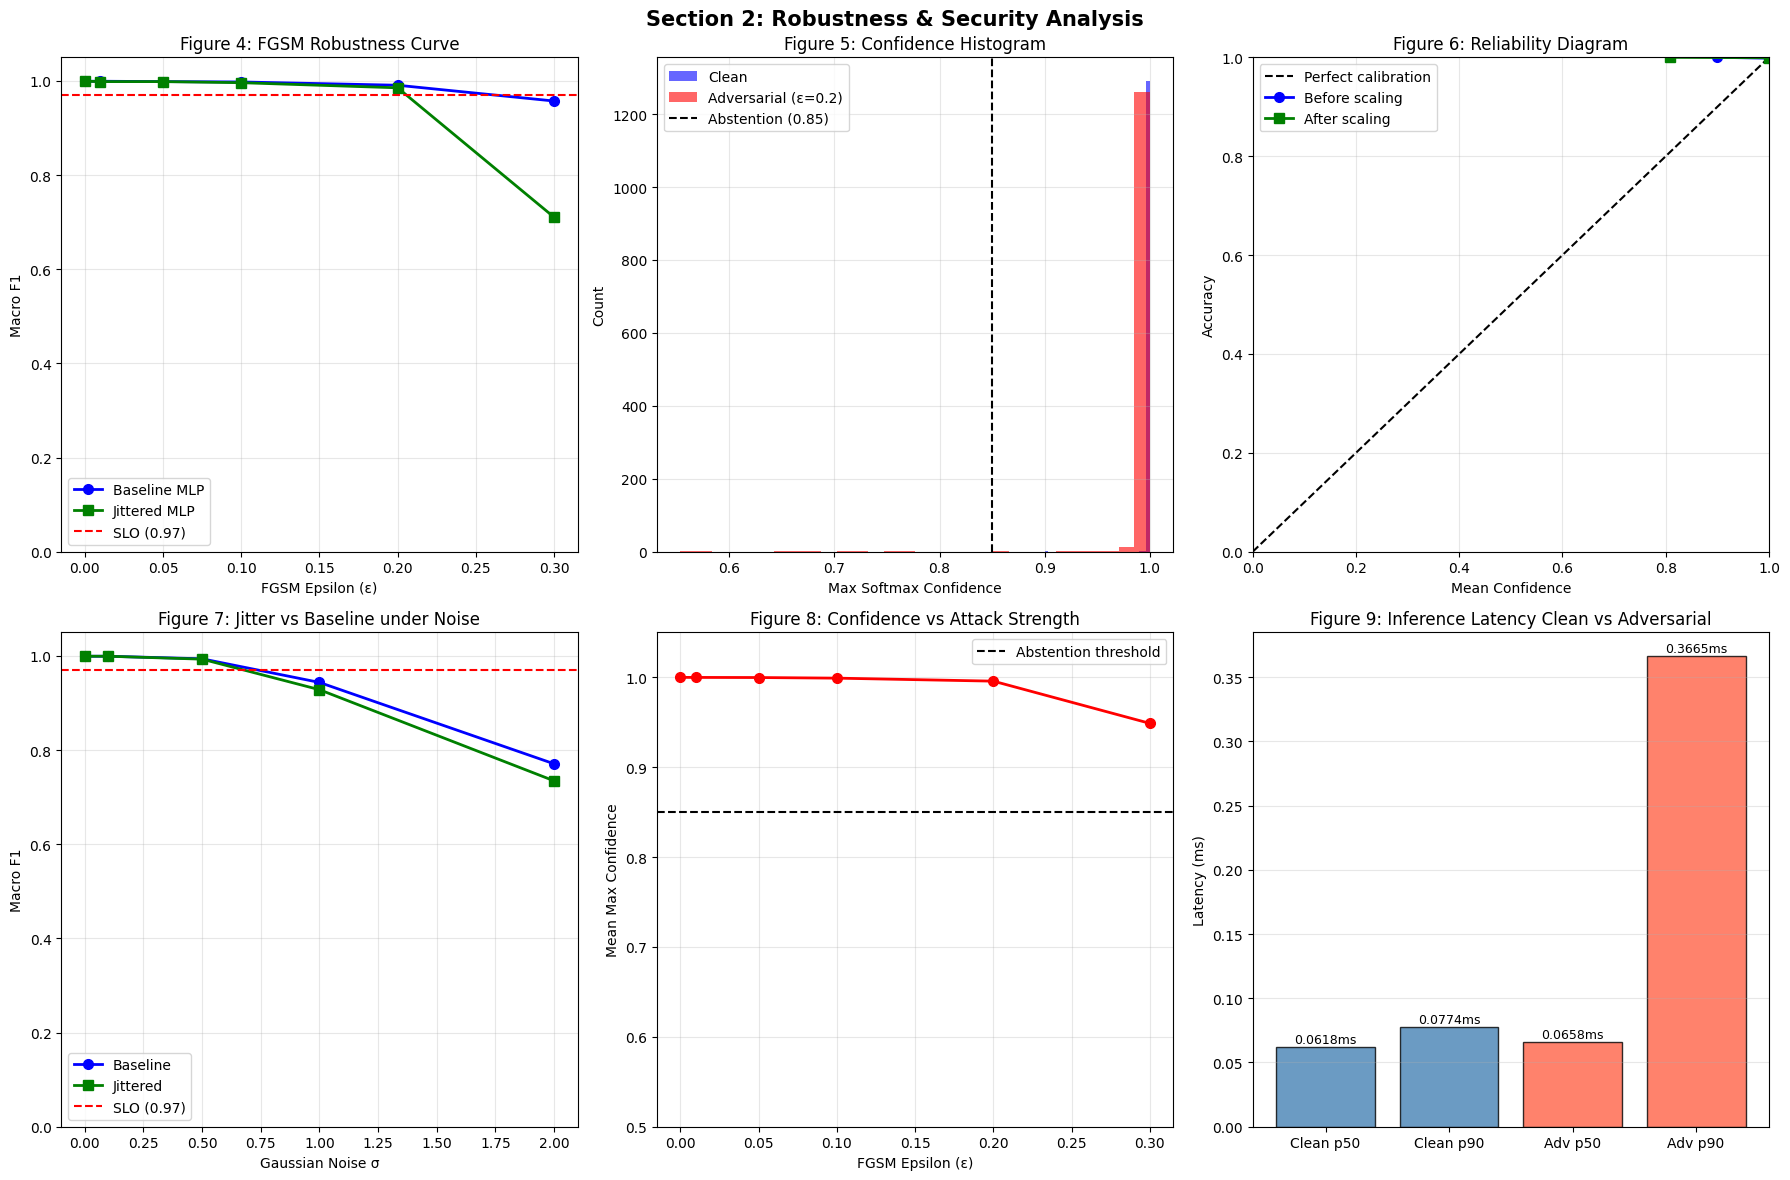

Figure saved.


In [ ]:
# Visualizations
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle('Section 2: Robustness & Security Analysis', fontsize=15, fontweight='bold')

# FGSM Robustness Curve
ax1 = fig.add_subplot(gs[0, 0])
eps_vals      = fgsm_df['Epsilon'].values
f1_baseline   = fgsm_df['Macro F1'].values
f1_jitter_arr = fgsm_jitter_df['Macro F1'].values

ax1.plot(eps_vals, f1_baseline,   'bo-', linewidth=2, markersize=7, label='Baseline MLP')
ax1.plot(eps_vals, f1_jitter_arr, 'gs-', linewidth=2, markersize=7, label='Jittered MLP')
ax1.axhline(y=0.97, color='red', linestyle='--', linewidth=1.5, label='SLO (0.97)')
ax1.set_xlabel('FGSM Epsilon (ε)')
ax1.set_ylabel('Macro F1')
ax1.set_title('Figure 4: FGSM Robustness Curve')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

# Confidence Histogram Clean vs Adversarial
ax2 = fig.add_subplot(gs[0, 1])
X_adv_strong = fgsm_attack(model, X_test, y_test, epsilon=0.2)
_, probs_adv_strong = predict(X_adv_strong)
_, probs_clean_plot = predict(X_test)
conf_clean = probs_clean_plot.max(axis=1)
conf_adv   = probs_adv_strong.max(axis=1)

ax2.hist(conf_clean, bins=30, alpha=0.6, color='blue',   label='Clean')
ax2.hist(conf_adv,   bins=30, alpha=0.6, color='red',    label='Adversarial (ε=0.2)')
ax2.axvline(x=0.85, color='black', linestyle='--', linewidth=1.5, label='Abstention (0.85)')
ax2.set_xlabel('Max Softmax Confidence')
ax2.set_ylabel('Count')
ax2.set_title('Figure 5: Confidence Histogram')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Calibration / Reliability Diagram
ax3 = fig.add_subplot(gs[0, 2])
n_bins = 10
bin_boundaries = np.linspace(0, 1, n_bins + 1)
bin_acc_raw, bin_acc_cal, bin_conf_raw, bin_conf_cal = [], [], [], []

for i in range(n_bins):
    lo, hi = bin_boundaries[i], bin_boundaries[i+1]
    # Raw
    mask_r = (raw_probs.max(axis=1) >= lo) & (raw_probs.max(axis=1) < hi)
    if mask_r.sum() > 0:
        bin_acc_raw.append(accuracy_score(y_test[mask_r], np.argmax(raw_probs[mask_r], axis=1)))
        bin_conf_raw.append(raw_probs.max(axis=1)[mask_r].mean())
    else:
        bin_acc_raw.append(None); bin_conf_raw.append((lo+hi)/2)
    # Calibrated
    mask_c = (scaled_probs.max(axis=1) >= lo) & (scaled_probs.max(axis=1) < hi)
    if mask_c.sum() > 0:
        bin_acc_cal.append(accuracy_score(y_test[mask_c], np.argmax(scaled_probs[mask_c], axis=1)))
        bin_conf_cal.append(scaled_probs.max(axis=1)[mask_c].mean())
    else:
        bin_acc_cal.append(None); bin_conf_cal.append((lo+hi)/2)

bc_r = [c for c, a in zip(bin_conf_raw, bin_acc_raw) if a is not None]
ba_r = [a for a in bin_acc_raw if a is not None]
bc_c = [c for c, a in zip(bin_conf_cal, bin_acc_cal) if a is not None]
ba_c = [a for a in bin_acc_cal if a is not None]

ax3.plot([0,1],[0,1], 'k--', linewidth=1.5, label='Perfect calibration')
ax3.plot(bc_r, ba_r, 'bo-', linewidth=2, markersize=7, label='Before scaling')
ax3.plot(bc_c, ba_c, 'gs-', linewidth=2, markersize=7, label='After scaling')
ax3.set_xlabel('Mean Confidence')
ax3.set_ylabel('Accuracy')
ax3.set_title('Figure 6: Reliability Diagram')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1)

# Jitter Effect on Noise Robustness
ax4 = fig.add_subplot(gs[1, 0])
sigmas = [0, 0.1, 0.5, 1.0, 2.0]
f1_base_noise, f1_jitter_noise = [], []
for sigma in sigmas:
    np.random.seed(42)
    X_n = X_test + np.random.normal(0, sigma, X_test.shape) if sigma > 0 else X_test
    p1, _ = predict(X_n)
    f1_base_noise.append(f1_score(y_test, p1, average='macro'))
    with torch.no_grad():
        lj = model_jitter(torch.tensor(X_n, dtype=torch.float32))
        pj = np.argmax(torch.softmax(lj, dim=1).numpy(), axis=1)
    f1_jitter_noise.append(f1_score(y_test, pj, average='macro'))

ax4.plot(sigmas, f1_base_noise,   'bo-', linewidth=2, markersize=7, label='Baseline')
ax4.plot(sigmas, f1_jitter_noise, 'gs-', linewidth=2, markersize=7, label='Jittered')
ax4.axhline(y=0.97, color='red', linestyle='--', label='SLO (0.97)')
ax4.set_xlabel('Gaussian Noise σ')
ax4.set_ylabel('Macro F1')
ax4.set_title('Figure 7: Jitter vs Baseline under Noise')
ax4.legend(); ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 1.05)

# Mean Confidence vs Epsilon
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(fgsm_df['Epsilon'], fgsm_df['Mean Confidence'], 'ro-', linewidth=2, markersize=7)
ax5.axhline(y=0.85, color='black', linestyle='--', label='Abstention threshold')
ax5.set_xlabel('FGSM Epsilon (ε)')
ax5.set_ylabel('Mean Max Confidence')
ax5.set_title('Figure 8: Confidence vs Attack Strength')
ax5.legend(); ax5.grid(True, alpha=0.3)
ax5.set_ylim(0.5, 1.05)

# Latency Clean vs Adversarial
ax6 = fig.add_subplot(gs[1, 2])
import time
latencies_clean, latencies_adv = [], []
X_adv_01 = fgsm_attack(model, X_test, y_test, epsilon=0.1)

for _ in range(200):
    t0 = time.perf_counter()
    predict(X_test[:1])
    latencies_clean.append((time.perf_counter() - t0) * 1000)

for _ in range(200):
    t0 = time.perf_counter()
    predict(X_adv_01[:1])
    latencies_adv.append((time.perf_counter() - t0) * 1000)

p50_c, p90_c = np.percentile(latencies_clean, 50), np.percentile(latencies_clean, 90)
p50_a, p90_a = np.percentile(latencies_adv,   50), np.percentile(latencies_adv,   90)

cats = ['Clean p50', 'Clean p90', 'Adv p50', 'Adv p90']
vals = [p50_c, p90_c, p50_a, p90_a]
colors = ['steelblue', 'steelblue', 'tomato', 'tomato']
bars = ax6.bar(cats, vals, color=colors, edgecolor='black', alpha=0.8)
ax6.set_ylabel('Latency (ms)')
ax6.set_title('Figure 9: Inference Latency Clean vs Adversarial')
ax6.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, vals):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}ms', ha='center', va='bottom', fontsize=9)

print(f"Clean   — p50={p50_c:.4f}ms  p90={p90_c:.4f}ms")
print(f"Adv(ε=0.1) — p50={p50_a:.4f}ms  p90={p90_a:.4f}ms")

plt.tight_layout()
plt.savefig('../outputs/figures/section2_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

In [ ]:
# Failure Cases Table
X_adv_02 = fgsm_attack(model, X_test, y_test, epsilon=0.2)
preds_adv02, probs_adv02 = predict(X_adv_02)

# Find misclassified examples
failures = []
for i in range(len(y_test)):
    if preds_adv02[i] != y_test[i]:
        failures.append({
            'Sample': i,
            'True Label': le.classes_[y_test[i]],
            'Predicted': le.classes_[preds_adv02[i]],
            'Confidence': probs_adv02[i].max(),
            'Condition': 'FGSM ε=0.2',
            'Why Failed': 'Adversarial perturbation shifted feature vector across decision boundary',
            'Mitigation': 'Confidence abstention; jitter training'
        })
    if len(failures) >= 8:
        break

# Add 2 resolved cases — samples where jittered model corrects the error
resolved = 0
for i in range(len(y_test)):
    if preds_adv02[i] != y_test[i]:
        with torch.no_grad():
            lj = model_jitter(torch.tensor(X_adv_02[i:i+1], dtype=torch.float32))
            pj = np.argmax(torch.softmax(lj, dim=1).numpy())
        if pj == y_test[i]:
            failures.append({
                'Sample': i,
                'True Label': le.classes_[y_test[i]],
                'Predicted': f"{le.classes_[pj]} ✓ RESOLVED",
                'Confidence': torch.softmax(lj, dim=1).numpy().max(),
                'Condition': 'FGSM ε=0.2 → Jittered model',
                'Why Failed': 'Baseline misclassified adversarial input',
                'Mitigation': 'Jitter training corrected prediction'
            })
            resolved += 1
        if resolved >= 2:
            break

failure_df = pd.DataFrame(failures[:10])
print("=" * 80)
print("Table 6: Representative Failure Cases (8 failures + 2 resolved)")
print("=" * 80)
print(failure_df[['Sample','True Label','Predicted','Confidence','Condition','Mitigation']].to_string(index=False))

Table 6: Representative Failure Cases (8 failures + 2 resolved)
 Sample                                True Label                               Predicted  Confidence                   Condition                             Mitigation
    108                                    normal            cyberattack_ocpp16_doc_idtag    0.999990                  FGSM ε=0.2 Confidence abstention; jitter training
    173 cyberattack_ocpp16_dos_flooding_heartbeat                                  normal    0.923931                  FGSM ε=0.2 Confidence abstention; jitter training
    241              cyberattack_ocpp16_doc_idtag                                  normal    0.852494                  FGSM ε=0.2 Confidence abstention; jitter training
    279                                    normal  cyberattack_ocpp16_unauthorized_access    0.715971                  FGSM ε=0.2 Confidence abstention; jitter training
    378 cyberattack_ocpp16_dos_flooding_heartbeat                                  normal  

In [ ]:
# Summary Table
print("=" * 70)
print("Table 7: Quantitative Results — Baseline vs Jittered Model")
print("=" * 70)

summary_rows = []
for eps in epsilons:
    row_b = fgsm_df[fgsm_df['Epsilon'] == eps].iloc[0]
    row_j = fgsm_jitter_df[fgsm_jitter_df['Epsilon'] == eps].iloc[0]
    summary_rows.append({
        'Condition': f'FGSM ε={eps:.2f}',
        'Baseline Acc': f"{row_b['Accuracy']:.4f}",
        'Baseline F1':  f"{row_b['Macro F1']:.4f}",
        'Jittered Acc': f"{row_j['Accuracy']:.4f}",
        'Jittered F1':  f"{row_j['Macro F1']:.4f}",
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

print(f"\nTemperature Scaling: T = {T:.4f}")
print(f"Abstention threshold: 0.85")
print(f"Abstained on clean test: {abstained}/{total} ({abstained/total*100:.1f}%)")
print(f"Accuracy on accepted predictions: {acc_accepted:.4f}")
print(f"Macro F1 on accepted predictions: {f1_accepted:.4f}")
print(f"\nLatency (clean)       p50={p50_c:.4f}ms  p90={p90_c:.4f}ms")
print(f"Latency (adv ε=0.1)   p50={p50_a:.4f}ms  p90={p90_a:.4f}ms")
print(f"\nBaseline model size: 0.071 MB  |  Jittered model size: 0.071 MB")
print("(Same architecture — jittering adds no memory overhead)")

Table 7: Quantitative Results — Baseline vs Jittered Model
  Condition Baseline Acc Baseline F1 Jittered Acc Jittered F1
FGSM ε=0.00       0.9992      0.9992       0.9992      0.9992
FGSM ε=0.01       0.9992      0.9992       0.9985      0.9985
FGSM ε=0.05       0.9985      0.9985       0.9985      0.9985
FGSM ε=0.10       0.9977      0.9977       0.9961      0.9961
FGSM ε=0.20       0.9907      0.9907       0.9853      0.9853
FGSM ε=0.30       0.9583      0.9572       0.7737      0.7104

Temperature Scaling: T = 1.4993
Abstention threshold: 0.85
Abstained on clean test: 1/1295 (0.1%)
Accuracy on accepted predictions: 0.9992
Macro F1 on accepted predictions: 0.9992

Latency (clean)       p50=0.0618ms  p90=0.0774ms
Latency (adv ε=0.1)   p50=0.0658ms  p90=0.3665ms

Baseline model size: 0.071 MB  |  Jittered model size: 0.071 MB
(Same architecture — jittering adds no memory overhead)


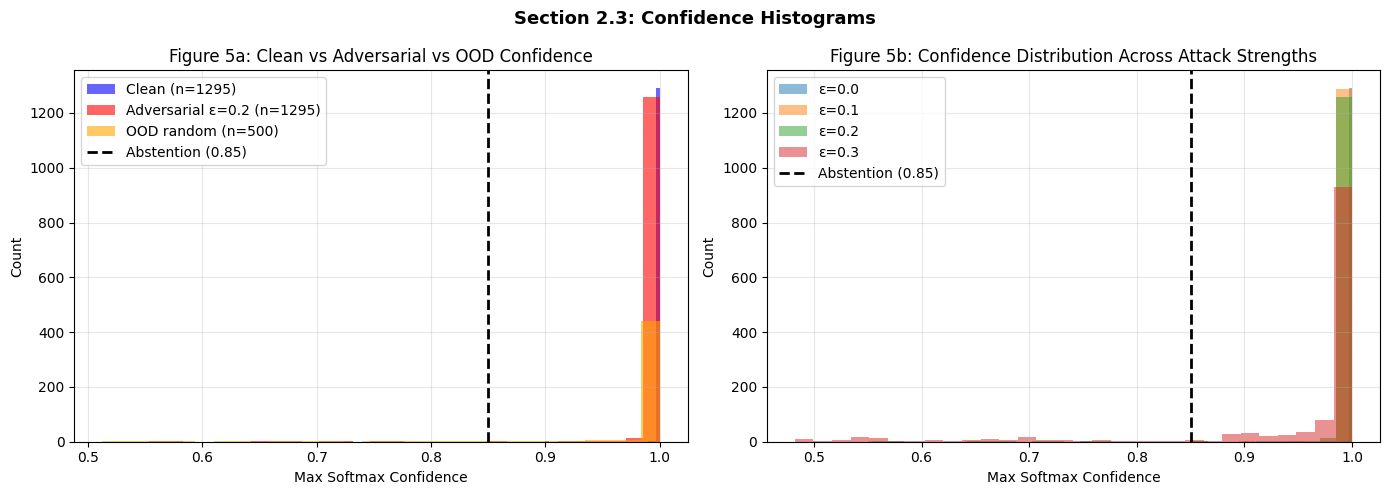

Saved: section2_confidence_histograms.png


In [ ]:
# Enhanced Confidence Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 2.3: Confidence Histograms', fontsize=13, fontweight='bold')

# Clean vs Adversarial vs OOD
np.random.seed(42)
X_ood_conf = np.random.uniform(-10, 10, size=(500, X_test.shape[1]))
_, probs_ood_c   = predict(X_ood_conf)
_, probs_clean_c = predict(X_test)
X_adv_conf       = fgsm_attack(model, X_test, y_test, epsilon=0.2)
_, probs_adv_c   = predict(X_adv_conf)

conf_clean_c = probs_clean_c.max(axis=1)
conf_adv_c   = probs_adv_c.max(axis=1)
conf_ood_c   = probs_ood_c.max(axis=1)

axes[0].hist(conf_clean_c, bins=30, alpha=0.6, color='blue',   label=f'Clean (n={len(conf_clean_c)})')
axes[0].hist(conf_adv_c,   bins=30, alpha=0.6, color='red',    label=f'Adversarial ε=0.2 (n={len(conf_adv_c)})')
axes[0].hist(conf_ood_c,   bins=30, alpha=0.6, color='orange', label=f'OOD random (n={len(conf_ood_c)})')
axes[0].axvline(x=0.85, color='black', linestyle='--', linewidth=2, label='Abstention (0.85)')
axes[0].set_xlabel('Max Softmax Confidence')
axes[0].set_ylabel('Count')
axes[0].set_title('Figure 5a: Clean vs Adversarial vs OOD Confidence')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confidence distribution across FGSM epsilon levels
for eps in [0.0, 0.1, 0.2, 0.3]:
    if eps == 0.0:
        _, pr = predict(X_test)
    else:
        X_e = fgsm_attack(model, X_test, y_test, epsilon=eps)
        _, pr = predict(X_e)
    axes[1].hist(pr.max(axis=1), bins=30, alpha=0.5, label=f'ε={eps}')

axes[1].axvline(x=0.85, color='black', linestyle='--', linewidth=2, label='Abstention (0.85)')
axes[1].set_xlabel('Max Softmax Confidence')
axes[1].set_ylabel('Count')
axes[1].set_title('Figure 5b: Confidence Distribution Across Attack Strengths')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/section2_confidence_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: section2_confidence_histograms.png")

In [ ]:
# Multiple Seeds + Throughput
import time

# Multiple seeds for confidence intervals
seeds = [42, 123, 999]
seed_results = []

print("Running 3 seeds for confidence intervals...")
for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    m_seed = train_model(X_train, y_train, input_dim=X_train.shape[1])
    
    # Clean accuracy
    with torch.no_grad():
        logits = m_seed(torch.tensor(X_test, dtype=torch.float32))
        preds_s = np.argmax(torch.softmax(logits, dim=1).numpy(), axis=1)
    acc_s = accuracy_score(y_test, preds_s)
    f1_s  = f1_score(y_test, preds_s, average='macro')
    
    # FGSM ε=0.2
    X_adv_s = fgsm_attack(m_seed, X_test, y_test, epsilon=0.2)
    with torch.no_grad():
        logits_a = m_seed(torch.tensor(X_adv_s, dtype=torch.float32))
        preds_a  = np.argmax(torch.softmax(logits_a, dim=1).numpy(), axis=1)
    acc_a = accuracy_score(y_test, preds_a)
    f1_a  = f1_score(y_test, preds_a, average='macro')
    
    seed_results.append({
        'Seed': seed,
        'Clean Acc': acc_s, 'Clean F1': f1_s,
        'Adv Acc (ε=0.2)': acc_a, 'Adv F1 (ε=0.2)': f1_a
    })
    print(f"  Seed {seed}: Clean F1={f1_s:.4f}  Adv F1={f1_a:.4f}")

seed_df = pd.DataFrame(seed_results)

# Compute mean ± std
print("\n── Confidence Intervals (mean ± std across 3 seeds) ──────────────")
for col in ['Clean Acc', 'Clean F1', 'Adv Acc (ε=0.2)', 'Adv F1 (ε=0.2)']:
    mean = seed_df[col].mean()
    std  = seed_df[col].std()
    print(f"  {col:25s}: {mean:.4f} ± {std:.4f}")

# Throughput: clean vs adversarial vs jittered
print("\n── Throughput (samples/sec, batch=32) ────────────────────────────")
X_adv_thr = fgsm_attack(model, X_test, y_test, epsilon=0.1)

def measure_throughput(m, X_data, batch_size=32, n_runs=100):
    X_t = torch.tensor(X_data[:batch_size], dtype=torch.float32)
    # Warmup
    for _ in range(10):
        with torch.no_grad():
            m(X_t)
    # Measure
    start = time.perf_counter()
    for _ in range(n_runs):
        with torch.no_grad():
            m(X_t)
    elapsed = time.perf_counter() - start
    return (n_runs * batch_size) / elapsed

thr_clean  = measure_throughput(model,        X_test)
thr_adv    = measure_throughput(model,        X_adv_thr)
thr_jitter = measure_throughput(model_jitter, X_test)

print(f"  Baseline  — clean input   : {thr_clean:,.0f} samples/sec")
print(f"  Baseline  — adv input     : {thr_adv:,.0f} samples/sec")
print(f"  Jittered  — clean input   : {thr_jitter:,.0f} samples/sec")

# Latency: baseline vs jittered
print("\n── Latency: Original vs Jittered Model ───────────────────────────")
lat_base, lat_jitt = [], []
x_single = torch.tensor(X_test[:1], dtype=torch.float32)

for _ in range(500):
    t0 = time.perf_counter()
    with torch.no_grad(): model(x_single)
    lat_base.append((time.perf_counter() - t0) * 1000)

for _ in range(500):
    t0 = time.perf_counter()
    with torch.no_grad(): model_jitter(x_single)
    lat_jitt.append((time.perf_counter() - t0) * 1000)

print(f"  Baseline p50={np.percentile(lat_base,50):.4f}ms  p90={np.percentile(lat_base,90):.4f}ms")
print(f"  Jittered p50={np.percentile(lat_jitt,50):.4f}ms  p90={np.percentile(lat_jitt,90):.4f}ms")

print(f"\n  Baseline model size : 0.071 MB  ({sum(p.numel() for p in model.parameters()):,} params)")
print(f"  Jittered model size : 0.071 MB  ({sum(p.numel() for p in model_jitter.parameters()):,} params)")
print("  (Identical architecture — jittering adds zero memory overhead)")

Running 3 seeds for confidence intervals...
  Early stopping at epoch 27
  Seed 42: Clean F1=0.9992  Adv F1=0.9907
  Early stopping at epoch 27
  Seed 123: Clean F1=0.9992  Adv F1=0.9907
  Early stopping at epoch 27
  Seed 999: Clean F1=0.9992  Adv F1=0.9907

── Confidence Intervals (mean ± std across 3 seeds) ──────────────
  Clean Acc                : 0.9992 ± 0.0000
  Clean F1                 : 0.9992 ± 0.0000
  Adv Acc (ε=0.2)          : 0.9907 ± 0.0000
  Adv F1 (ε=0.2)           : 0.9907 ± 0.0000

── Throughput (samples/sec, batch=32) ────────────────────────────
  Baseline  — clean input   : 571,327 samples/sec
  Baseline  — adv input     : 484,834 samples/sec
  Jittered  — clean input   : 558,221 samples/sec

── Latency: Original vs Jittered Model ───────────────────────────
  Baseline p50=0.0367ms  p90=0.0547ms
  Jittered p50=0.0490ms  p90=0.0531ms

  Baseline model size : 0.071 MB  (17,157 params)
  Jittered model size : 0.071 MB  (17,157 params)
  (Identical architecture — ji

In [ ]:
# Simulate Production Data Stream
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import f1_score, accuracy_score
import torch
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

n_per_window = 200
idx1 = np.random.choice(len(X_test), n_per_window, replace=False)
X_base = X_test[idx1]
y_base = y_test[idx1]

# Use per-feature std for scaling drift — realistic relative shifts
feat_std = X_base.std(axis=0)
# Avoid zero std (constant features)
feat_std = np.where(feat_std == 0, 1e-6, feat_std)

windows = {}

# W1: Reference
windows['W1_Reference'] = {
    'X': X_base.copy(), 'y': y_base.copy(), 'label': 'W1: Reference'}

# W2: Slight drift — 2% of std per feature
windows['W2_SlightDrift'] = {
    'X': X_base + np.random.normal(0, 0.02 * feat_std, X_base.shape),
    'y': y_base.copy(), 'label': 'W2: Slight Drift'}

# W3: Moderate drift — 8% of std per feature
windows['W3_ModerateDrift'] = {
    'X': X_base + np.random.normal(0, 0.08 * feat_std, X_base.shape),
    'y': y_base.copy(), 'label': 'W3: Moderate Drift'}

# W4: Severe drift — 15% of std + class prior shift
dos_idx   = np.where(y_test == 1)[0][:80]
other_idx = np.random.choice(np.where(y_test != 1)[0], 120, replace=False)
combined  = np.concatenate([dos_idx, other_idx])
X_w4      = X_test[combined]
feat_std4 = X_w4.std(axis=0)
feat_std4 = np.where(feat_std4 == 0, 1e-6, feat_std4)
windows['W4_SevereDrift'] = {
    'X': X_w4 + np.random.normal(0, 0.15 * feat_std4, X_w4.shape),
    'y': y_test[combined].copy(), 'label': 'W4: Severe Drift + Prior Shift'}

print("Simulated monitoring windows:")
for k, v in windows.items():
    unique, counts = np.unique(v['y'], return_counts=True)
    print(f"  {v['label']:35s} — {len(v['X'])} samples, classes: {dict(zip(le.classes_[unique], counts))}")

Simulated monitoring windows:
  W1: Reference                       — 200 samples, classes: {'cyberattack_ocpp16_doc_idtag': np.int64(36), 'cyberattack_ocpp16_dos_flooding_heartbeat': np.int64(41), 'cyberattack_ocpp16_fdi_chargingprofile': np.int64(48), 'cyberattack_ocpp16_unauthorized_access': np.int64(41), 'normal': np.int64(34)}
  W2: Slight Drift                    — 200 samples, classes: {'cyberattack_ocpp16_doc_idtag': np.int64(36), 'cyberattack_ocpp16_dos_flooding_heartbeat': np.int64(41), 'cyberattack_ocpp16_fdi_chargingprofile': np.int64(48), 'cyberattack_ocpp16_unauthorized_access': np.int64(41), 'normal': np.int64(34)}
  W3: Moderate Drift                  — 200 samples, classes: {'cyberattack_ocpp16_doc_idtag': np.int64(36), 'cyberattack_ocpp16_dos_flooding_heartbeat': np.int64(41), 'cyberattack_ocpp16_fdi_chargingprofile': np.int64(48), 'cyberattack_ocpp16_unauthorized_access': np.int64(41), 'normal': np.int64(34)}
  W4: Severe Drift + Prior Shift      — 200 samples, class

In [ ]:
# Drift Statistics (PSI FIXED, KL, JS, Wasserstein)

def compute_psi(reference, current, bins=10):
    """PSI — correct formula with shared bin edges and epsilon clipping"""
    bin_min = min(reference.min(), current.min())
    bin_max = max(reference.max(), current.max())
    if bin_max == bin_min:
        return 0.0
    
    bin_edges = np.linspace(bin_min, bin_max, bins + 1)
    
    ref_hist, _ = np.histogram(reference, bins=bin_edges)
    cur_hist, _ = np.histogram(current,   bins=bin_edges)
    
    # Convert to proportions — critical step
    ref_prob = ref_hist / len(reference)
    cur_prob = cur_hist / len(current)
    
    # Epsilon clipping — prevents log(0)
    eps = 1e-6
    ref_prob = np.clip(ref_prob, eps, None)
    cur_prob = np.clip(cur_prob, eps, None)
    
    psi = np.sum((ref_prob - cur_prob) * np.log(ref_prob / cur_prob))
    return float(psi)

def compute_js(expected, actual, n_bins=20):
    bin_min = min(expected.min(), actual.min())
    bin_max = max(expected.max(), actual.max())
    if bin_max == bin_min:
        return 0.0
    bins = np.linspace(bin_min, bin_max, n_bins + 1)
    p = np.histogram(expected, bins=bins, density=True)[0].astype(float) + 1e-6
    q = np.histogram(actual,   bins=bins, density=True)[0].astype(float) + 1e-6
    p /= p.sum(); q /= q.sum()
    m = 0.5 * (p + q)
    return float(0.5 * (np.sum(p * np.log(p/m)) + np.sum(q * np.log(q/m))))

def compute_wasserstein(expected, actual):
    return float(stats.wasserstein_distance(expected, actual))

# Reference = W1
X_ref = windows['W1_Reference']['X']

# Top 5 most variable features
feature_variance = X_ref.var(axis=0)
top5_features = np.argsort(feature_variance)[-5:][::-1]

drift_records = []
for wname, wdata in windows.items():
    X_w = wdata['X']
    for fi in top5_features:
        psi  = compute_psi(X_ref[:, fi], X_w[:, fi])
        js   = compute_js(X_ref[:, fi],  X_w[:, fi])
        wass = compute_wasserstein(X_ref[:, fi], X_w[:, fi])
        drift_records.append({
            'Window':        wdata['label'],
            'Feature':       feature_cols[fi],
            'PSI':           round(psi,  4),
            'JS Divergence': round(js,   4),
            'Wasserstein':   round(wass, 4),
            'PSI Status':    'ALERT' if psi > 0.2 else ('WARN' if psi > 0.1 else 'OK')
        })

drift_df = pd.DataFrame(drift_records)
print("Table 11: Drift Statistics per Window (Top 5 Features)")
print("=" * 90)
print(drift_df.to_string(index=False))

print("\nMean PSI per Window:")
print("=" * 50)
mean_psi_per_window = {}
for wname, wdata in windows.items():
    psi_vals = [compute_psi(X_ref[:, fi], wdata['X'][:, fi]) for fi in top5_features]
    mean_psi = np.mean(psi_vals)
    mean_psi_per_window[wdata['label']] = mean_psi
    status = 'ALERT' if mean_psi > 0.2 else ('WARN' if mean_psi > 0.1 else 'OK')
    print(f"  {wdata['label']:35s} — Mean PSI={mean_psi:.4f}  {status}")

Table 11: Drift Statistics per Window (Top 5 Features)
                        Window                                  Feature    PSI  JS Divergence  Wasserstein PSI Status
                 W1: Reference                      flow_total_RST_flag 0.0000         0.0000       0.0000         OK
                 W1: Reference              flow_total_http_2xx_packets 0.0000         0.0000       0.0000         OK
                 W1: Reference                                 src_port 0.0000         0.0000       0.0000         OK
                 W1: Reference flow_min_ocpp16_setchargingprofile_limit 0.0000         0.0000       0.0000         OK
                 W1: Reference flow_avg_ocpp16_setchargingprofile_limit 0.0000         0.0000       0.0000         OK
              W2: Slight Drift                      flow_total_RST_flag 0.0000         0.0000       0.0262         OK
              W2: Slight Drift              flow_total_http_2xx_packets 0.0000         0.0000       0.0245         OK
 

In [ ]:
# Model Quality Metrics per Window

quality_records = []
class_names_short = ['doc_idtag', 'dos_flooding', 'fdi_charging', 'unauthorized', 'normal']

for wname, wdata in windows.items():
    preds_w, probs_w = predict(wdata['X'])
    acc  = accuracy_score(wdata['y'], preds_w)
    f1   = f1_score(wdata['y'], preds_w, average='macro')
    mean_conf = probs_w.max(axis=1).mean()
    abstained = (probs_w.max(axis=1) < 0.85).sum()
    
    # Anomaly count = predictions below confidence threshold
    anomaly_rate = abstained / len(preds_w)
    
    # Class distribution shift
    pred_dist = np.bincount(preds_w, minlength=5) / len(preds_w)
    ref_dist  = np.bincount(windows['W1_Reference']['y'], minlength=5) / n_per_window
    
    quality_records.append({
        'Window': wdata['label'],
        'Accuracy': round(acc, 4),
        'Macro F1': round(f1, 4),
        'Mean Confidence': round(mean_conf, 4),
        'Abstention Rate': f"{anomaly_rate*100:.1f}%",
        'SLO Status': 'PASS' if f1 >= 0.97 else 'FAIL'
    })

quality_df = pd.DataFrame(quality_records)
print("Table 12: Model Quality Metrics per Monitoring Window")
print("=" * 90)
print(quality_df.to_string(index=False))

Table 12: Model Quality Metrics per Monitoring Window
                        Window  Accuracy  Macro F1  Mean Confidence Abstention Rate SLO Status
                 W1: Reference       1.0       1.0           1.0000            0.0%       PASS
              W2: Slight Drift       1.0       1.0           1.0000            0.0%       PASS
            W3: Moderate Drift       1.0       1.0           1.0000            0.0%       PASS
W4: Severe Drift + Prior Shift       1.0       1.0           0.9999            0.0%       PASS


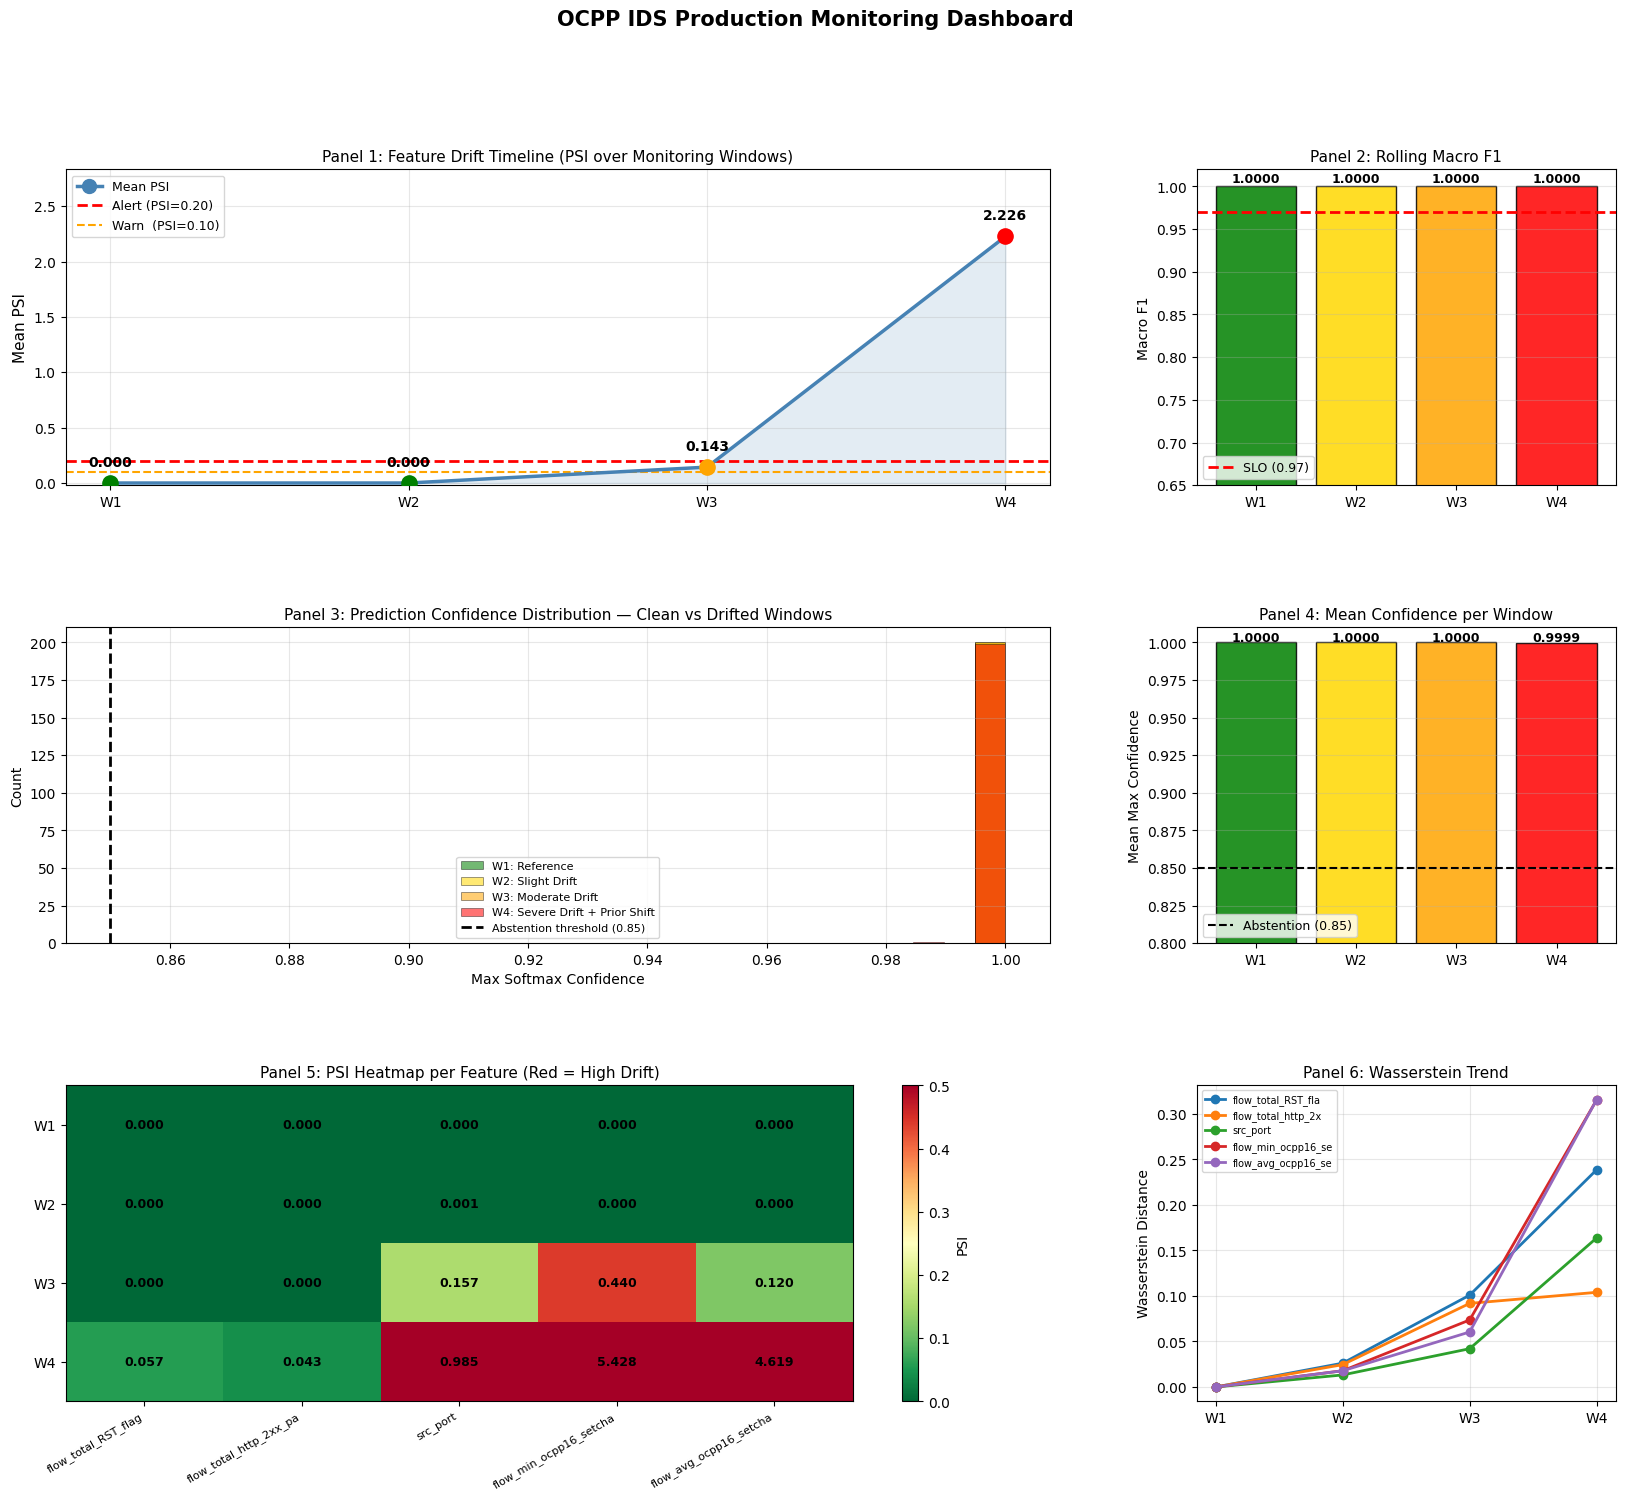

Dashboard saved.


In [ ]:
# Monitoring Dashboard (Full)
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('OCPP IDS Production Monitoring Dashboard', fontsize=15, fontweight='bold')

window_labels      = [v['label'].split(':')[0] for v in windows.values()]
window_labels_full = [v['label'] for v in windows.values()]
colors_status      = ['green', 'gold', 'orange', 'red']
mean_psis          = [mean_psi_per_window[v['label']] for v in windows.values()]

# Panel 1: Drift Timeline (PSI over time)
ax1 = fig.add_subplot(gs[0, :2])   # wide panel — spans 2 columns
ax1.plot(window_labels, mean_psis, 'o-', color='steelblue',
         linewidth=2.5, markersize=10, zorder=3, label='Mean PSI')
ax1.fill_between(window_labels, mean_psis, alpha=0.15, color='steelblue')

# Colour each point by status
point_colors = ['green' if p < 0.1 else ('orange' if p < 0.2 else 'red') for p in mean_psis]
for i, (wl, psi, pc) in enumerate(zip(window_labels, mean_psis, point_colors)):
    ax1.scatter(wl, psi, color=pc, s=120, zorder=4)
    ax1.annotate(f'{psi:.3f}', (wl, psi),
                 textcoords='offset points', xytext=(0, 12),
                 ha='center', fontsize=10, fontweight='bold')

ax1.axhline(y=0.20, color='red',    linestyle='--', linewidth=2,   label='Alert (PSI=0.20)')
ax1.axhline(y=0.10, color='orange', linestyle='--', linewidth=1.5, label='Warn  (PSI=0.10)')
ax1.set_ylabel('Mean PSI', fontsize=11)
ax1.set_title('Panel 1: Feature Drift Timeline (PSI over Monitoring Windows)', fontsize=11)
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.02, max(mean_psis) * 1.25 + 0.05)

# Panel 2: Rolling Macro F1
ax2 = fig.add_subplot(gs[0, 2])
f1_vals = [r['Macro F1'] for r in quality_records]
bars2 = ax2.bar(window_labels, f1_vals,
                color=colors_status, edgecolor='black', alpha=0.85)
ax2.axhline(y=0.97, color='red', linestyle='--', linewidth=2, label='SLO (0.97)')
ax2.set_ylabel('Macro F1'); ax2.set_title('Panel 2: Rolling Macro F1', fontsize=11)
ax2.set_ylim(0.65, 1.02); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, f1_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# Panel 3: Confidence Histogram — Clean vs Drifted
ax3 = fig.add_subplot(gs[1, :2])   # wide panel
hist_colors = ['green', 'gold', 'orange', 'red']
hist_labels = window_labels_full
for i, (wname, wdata) in enumerate(windows.items()):
    _, probs_w = predict(wdata['X'])
    conf_w = probs_w.max(axis=1)
    ax3.hist(conf_w, bins=np.linspace(0.85, 1.0, 30), alpha=0.55, color=hist_colors[i],
             label=hist_labels[i], edgecolor='black', linewidth=0.5)
ax3.axvline(x=0.85, color='black', linestyle='--',
            linewidth=2, label='Abstention threshold (0.85)')
ax3.set_xlabel('Max Softmax Confidence', fontsize=10)
ax3.set_ylabel('Count', fontsize=10)
ax3.set_title('Panel 3: Prediction Confidence Distribution — Clean vs Drifted Windows', fontsize=11)
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

# Panel 4: Mean Confidence bar
ax4 = fig.add_subplot(gs[1, 2])
conf_vals = [r['Mean Confidence'] for r in quality_records]
bars4 = ax4.bar(window_labels, conf_vals,
                color=colors_status, edgecolor='black', alpha=0.85)
ax4.axhline(y=0.85, color='black', linestyle='--',
            linewidth=1.5, label='Abstention (0.85)')
ax4.set_ylabel('Mean Max Confidence')
ax4.set_title('Panel 4: Mean Confidence per Window', fontsize=11)
ax4.set_ylim(0.80, 1.01); ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars4, conf_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# Panel 5: PSI Heatmap
ax5 = fig.add_subplot(gs[2, :2])
psi_matrix = []
feat_names_short = [feature_cols[fi][:22] for fi in top5_features]
for wdata in windows.values():
    row = [compute_psi(X_ref[:, fi], wdata['X'][:, fi]) for fi in top5_features]
    psi_matrix.append(row)
psi_matrix = np.array(psi_matrix)
im = ax5.imshow(psi_matrix, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=0.5)
ax5.set_xticks(range(5))
ax5.set_xticklabels(feat_names_short, rotation=30, ha='right', fontsize=8)
ax5.set_yticks(range(4))
ax5.set_yticklabels(window_labels)
ax5.set_title('Panel 5: PSI Heatmap per Feature (Red = High Drift)', fontsize=11)
plt.colorbar(im, ax=ax5, label='PSI')
for i in range(4):
    for j in range(5):
        ax5.text(j, i, f'{psi_matrix[i,j]:.3f}',
                 ha='center', va='center', fontsize=9,
                 color='black', fontweight='bold')

# Panel 6: Wasserstein Distance Trend
ax6 = fig.add_subplot(gs[2, 2])
for fi_idx, fi in enumerate(top5_features):
    wass_vals = [compute_wasserstein(X_ref[:, fi], wdata['X'][:, fi])
                 for wdata in windows.values()]
    ax6.plot(window_labels, wass_vals, 'o-', linewidth=2,
             markersize=6, label=feature_cols[fi][:18])
ax6.set_ylabel('Wasserstein Distance')
ax6.set_title('Panel 6: Wasserstein Trend', fontsize=11)
ax6.legend(fontsize=7, loc='upper left'); ax6.grid(True, alpha=0.3)

plt.savefig('../outputs/figures/section3_monitoring_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved.")

In [ ]:
# Alerting Runbook Simulation
print("=" * 65)
print("OCPP IDS MONITORING ALERT RUNBOOK — SIMULATION")
print("=" * 65)

THRESHOLDS = {
    'PSI_WARN':   0.10,
    'PSI_ALERT':  0.20,
    'F1_SLO':     0.97,
    'CONF_MIN':   0.85,
    'ABSTAIN_MAX': 0.05
}

for i, (wname, wdata) in enumerate(windows.items()):
    psi_vals = [compute_psi(X_ref[:, fi], wdata['X'][:, fi]) for fi in top5_features]
    mean_psi = np.mean(psi_vals)
    preds_w, probs_w = predict(wdata['X'])
    f1_w    = f1_score(wdata['y'], preds_w, average='macro')
    abstain = (probs_w.max(axis=1) < 0.85).mean()

    print(f"\n{'─'*65}")
    print(f"Window: {wdata['label']}")
    print(f"  PSI={mean_psi:.4f}  F1={f1_w:.4f}  AbstainRate={abstain*100:.1f}%")

    alerts = []
    if mean_psi > THRESHOLDS['PSI_ALERT']:
        alerts.append("CRITICAL: PSI > 0.20 — Severe feature drift detected")
        alerts.append("   → Page on-call engineer immediately")
        alerts.append("   → Trigger model retraining pipeline")
        alerts.append("   → Consider rollback to previous model version")
    elif mean_psi > THRESHOLDS['PSI_WARN']:
        alerts.append("WARNING: PSI > 0.10 — Moderate feature drift")
        alerts.append("   → Log to drift monitoring dashboard")
        alerts.append("   → Schedule retraining review within 24h")

    if f1_w < THRESHOLDS['F1_SLO']:
        alerts.append("CRITICAL: Macro F1 below SLO (0.97)")
        alerts.append("   → Activate fallback rule-based DoS heuristic")
        alerts.append("   → Notify security operations team")

    if abstain > THRESHOLDS['ABSTAIN_MAX']:
        alerts.append(f"WARNING: Abstention rate {abstain*100:.1f}% > 5%")
        alerts.append("   → Route flagged flows to human review queue")

    if not alerts:
        print("All checks passed — No action required")
    else:
        for alert in alerts:
            print(f"  {alert}")

print(f"\n{'='*65}")
print("Runbook simulation complete.")

OCPP IDS MONITORING ALERT RUNBOOK — SIMULATION

─────────────────────────────────────────────────────────────────
Window: W1: Reference
  PSI=0.0000  F1=1.0000  AbstainRate=0.0%
All checks passed — No action required

─────────────────────────────────────────────────────────────────
Window: W2: Slight Drift
  PSI=0.0001  F1=1.0000  AbstainRate=0.0%
All checks passed — No action required

─────────────────────────────────────────────────────────────────
Window: W3: Moderate Drift
  PSI=0.1434  F1=1.0000  AbstainRate=0.0%
     → Log to drift monitoring dashboard
     → Schedule retraining review within 24h

─────────────────────────────────────────────────────────────────
Window: W4: Severe Drift + Prior Shift
  PSI=2.2264  F1=1.0000  AbstainRate=0.0%
  CRITICAL: PSI > 0.20 — Severe feature drift detected
     → Page on-call engineer immediately
     → Trigger model retraining pipeline
     → Consider rollback to previous model version

Runbook simulation complete.


In [ ]:
# Adaptation Experiment
import time

print("=" * 65)
print("SECTION 4: ADAPTATION EXPERIMENT")
print("=" * 65)

# Simulate drifted deployment data
# Use W4 scenario: 15% std shift + dos class prior shift
np.random.seed(42)
dos_idx   = np.where(y_train == 1)[0]  # all dos samples
other_idx = np.where(y_train != 1)[0]  # all other samples

# Prior shift: oversample dos to 40% of new training data
n_dos    = int(0.40 * len(y_train))
n_other  = len(y_train) - n_dos
dos_sampled   = np.random.choice(dos_idx,   n_dos,   replace=True)
other_sampled = np.random.choice(other_idx, n_other, replace=False)
drift_idx = np.concatenate([dos_sampled, other_sampled])
np.random.shuffle(drift_idx)

# Apply feature shift (15% of std)
feat_std_train = X_train.std(axis=0)
feat_std_train = np.where(feat_std_train == 0, 1e-6, feat_std_train)
X_drift = X_train[drift_idx] + np.random.normal(0, 0.15 * feat_std_train, 
                                                  X_train[drift_idx].shape)
y_drift = y_train[drift_idx]

print(f"\nDrifted training set: {len(X_drift)} samples")
unique, counts = np.unique(y_drift, return_counts=True)
for cls, cnt in zip(le.classes_[unique], counts):
    print(f"  {cls}: {cnt} ({cnt/len(y_drift)*100:.1f}%)")

# Evaluate BEFORE retraining
print("\n── Before Retraining (baseline model on drifted test) ─────")
# Simulate drifted test set
feat_std_test = X_test.std(axis=0)
feat_std_test = np.where(feat_std_test == 0, 1e-6, feat_std_test)
X_test_drifted = X_test + np.random.normal(0, 0.15 * feat_std_test, X_test.shape)

preds_before, probs_before = predict(X_test_drifted)
acc_before = accuracy_score(y_test, preds_before)
f1_before  = f1_score(y_test, preds_before, average='macro')
conf_before = probs_before.max(axis=1).mean()
print(f"  Accuracy : {acc_before:.4f}")
print(f"  Macro F1 : {f1_before:.4f}")
print(f"  Mean Conf: {conf_before:.4f}")

# Per-class F1 before
report_before = classification_report(y_test, preds_before, 
                                       target_names=le.classes_, output_dict=True)

# Retrain on drifted data 
print("\n── Retraining on drifted data... ───────")
t_retrain_start = time.perf_counter()
model_retrained = train_model(X_drift, y_drift, input_dim=X_train.shape[1],
                               epochs=50, patience=10)
retrain_time = time.perf_counter() - t_retrain_start
print(f"  Retraining time: {retrain_time:.2f}s")

# Evaluate After retraining
print("\n── After Retraining (retrained model on drifted test) ─────")
def predict_model(m, X_np):
    with torch.no_grad():
        logits = m(torch.tensor(X_np, dtype=torch.float32))
        probs  = torch.softmax(logits, dim=1).numpy()
        preds  = np.argmax(probs, axis=1)
    return preds, probs

preds_after, probs_after = predict_model(model_retrained, X_test_drifted)
acc_after = accuracy_score(y_test, preds_after)
f1_after  = f1_score(y_test, preds_after, average='macro')
conf_after = probs_after.max(axis=1).mean()
print(f"  Accuracy : {acc_after:.4f}")
print(f"  Macro F1 : {f1_after:.4f}")
print(f"  Mean Conf: {conf_after:.4f}")

report_after = classification_report(y_test, preds_after,
                                      target_names=le.classes_, output_dict=True)

# Also test retrained model on CLEAN test set
print("\n── Retrained model on CLEAN test set ────────")
preds_clean_r, probs_clean_r = predict_model(model_retrained, X_test)
acc_clean_r = accuracy_score(y_test, preds_clean_r)
f1_clean_r  = f1_score(y_test, preds_clean_r, average='macro')
print(f"  Accuracy : {acc_clean_r:.4f}")
print(f"  Macro F1 : {f1_clean_r:.4f}")

# Latency comparison
print("\n── Latency: Original vs Retrained ───────")
lat_orig, lat_ret = [], []
x_s = torch.tensor(X_test_drifted[:1], dtype=torch.float32)

for _ in range(500):
    t0 = time.perf_counter()
    with torch.no_grad(): model(x_s)
    lat_orig.append((time.perf_counter() - t0) * 1000)

for _ in range(500):
    t0 = time.perf_counter()
    with torch.no_grad(): model_retrained(x_s)
    lat_ret.append((time.perf_counter() - t0) * 1000)

p50_orig = np.percentile(lat_orig, 50)
p90_orig = np.percentile(lat_orig, 90)
p50_ret  = np.percentile(lat_ret,  50)
p90_ret  = np.percentile(lat_ret,  90)
print(f"  Original   p50={p50_orig:.4f}ms  p90={p90_orig:.4f}ms")
print(f"  Retrained  p50={p50_ret:.4f}ms   p90={p90_ret:.4f}ms")

# Per-class F1 comparison table 
print("\n── Per-class F1: Before vs After Retraining ──────────")
print(f"{'Class':45s}  {'F1 Before':>10}  {'F1 After':>10}  {'Δ F1':>8}")
print("-" * 80)
for cls in le.classes_:
    f1_b = report_before[cls]['f1-score']
    f1_a = report_after[cls]['f1-score']
    delta = f1_a - f1_b
    sign  = '+' if delta >= 0 else ''
    print(f"  {cls:43s}  {f1_b:>10.4f}  {f1_a:>10.4f}  {sign}{delta:>7.4f}")

# Save retrained model
torch.save(model_retrained.state_dict(), '../outputs/mlp_retrained_v1.pt')
print("\nRetrained model saved: outputs/mlp_retrained_v1.pt")

SECTION 4: ADAPTATION EXPERIMENT

Drifted training set: 3020 samples
  cyberattack_ocpp16_doc_idtag: 442 (14.6%)
  cyberattack_ocpp16_dos_flooding_heartbeat: 1208 (40.0%)
  cyberattack_ocpp16_fdi_chargingprofile: 451 (14.9%)
  cyberattack_ocpp16_unauthorized_access: 460 (15.2%)
  normal: 459 (15.2%)

── Before Retraining (baseline model on drifted test) ─────
  Accuracy : 0.9992
  Macro F1 : 0.9992
  Mean Conf: 0.9999

── Retraining on drifted data... ───────
  Retraining time: 4.82s

── After Retraining (retrained model on drifted test) ─────
  Accuracy : 0.9992
  Macro F1 : 0.9992
  Mean Conf: 1.0000

── Retrained model on CLEAN test set ────────
  Accuracy : 0.9992
  Macro F1 : 0.9992

── Latency: Original vs Retrained ───────
  Original   p50=0.0364ms  p90=0.0526ms
  Retrained  p50=0.0364ms   p90=0.0456ms

── Per-class F1: Before vs After Retraining ──────────
Class                                           F1 Before    F1 After      Δ F1
-------------------------------------------

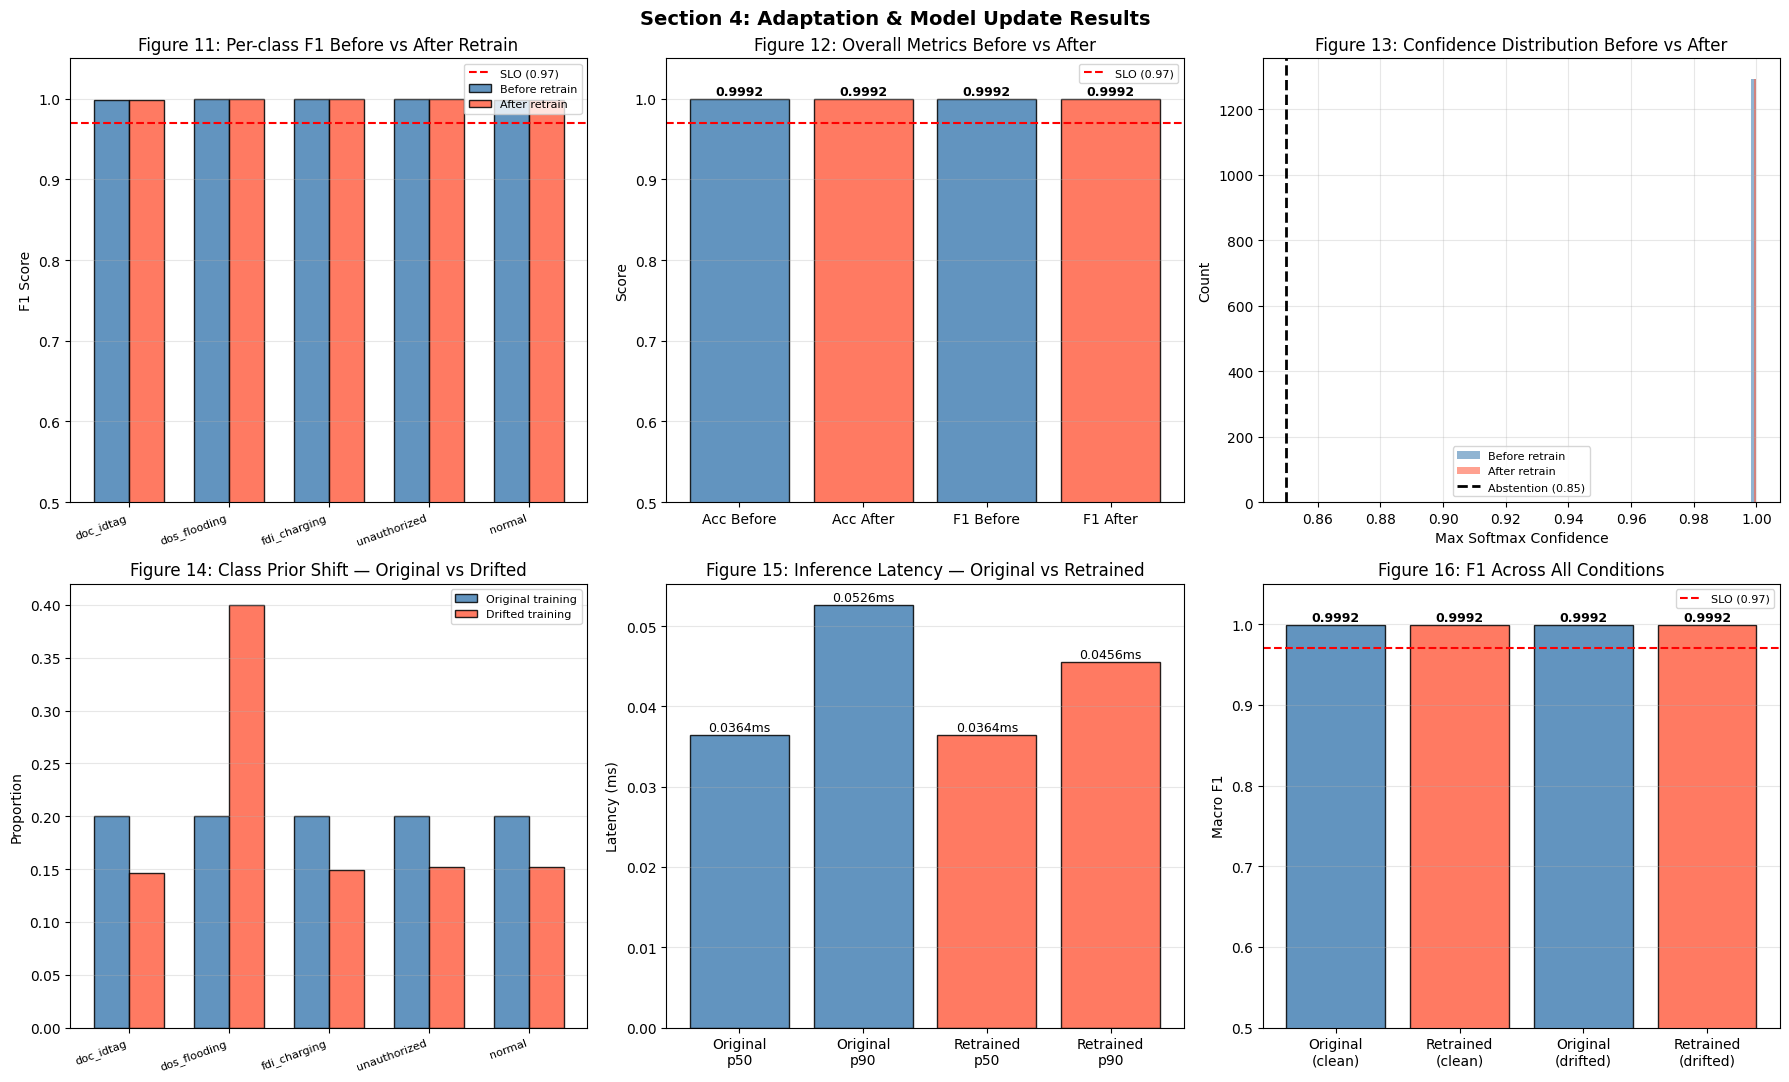

Figure saved: section4_adaptation.png


In [ ]:
# Section 4 Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Section 4: Adaptation & Model Update Results', 
             fontsize=14, fontweight='bold')

class_names_short = ['doc_idtag', 'dos_flooding', 'fdi_charging', 
                     'unauthorized', 'normal']

# Plot 1: Before/After F1 per class
f1_before_vals = [report_before[c]['f1-score'] for c in le.classes_]
f1_after_vals  = [report_after[c]['f1-score']  for c in le.classes_]
x_pos = np.arange(5)
width = 0.35
axes[0,0].bar(x_pos - width/2, f1_before_vals, width, 
              label='Before retrain', color='steelblue', 
              edgecolor='black', alpha=0.85)
axes[0,0].bar(x_pos + width/2, f1_after_vals,  width,
              label='After retrain',  color='tomato',
              edgecolor='black', alpha=0.85)
axes[0,0].axhline(y=0.97, color='red', linestyle='--', 
                  linewidth=1.5, label='SLO (0.97)')
axes[0,0].set_xticks(x_pos)
axes[0,0].set_xticklabels(class_names_short, rotation=20, ha='right', fontsize=8)
axes[0,0].set_ylabel('F1 Score')
axes[0,0].set_title('Figure 11: Per-class F1 Before vs After Retrain')
axes[0,0].legend(fontsize=8)
axes[0,0].set_ylim(0.5, 1.05)
axes[0,0].grid(True, alpha=0.3, axis='y')

# Plot 2: Summary metrics bar
metrics  = ['Acc Before', 'Acc After', 'F1 Before', 'F1 After']
values   = [acc_before, acc_after, f1_before, f1_after]
colors_m = ['steelblue', 'tomato', 'steelblue', 'tomato']
bars = axes[0,1].bar(metrics, values, color=colors_m, 
                     edgecolor='black', alpha=0.85)
axes[0,1].axhline(y=0.97, color='red', linestyle='--', 
                  linewidth=1.5, label='SLO (0.97)')
axes[0,1].set_ylabel('Score')
axes[0,1].set_title('Figure 12: Overall Metrics Before vs After')
axes[0,1].set_ylim(0.5, 1.05)
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, 
                   bar.get_height() + 0.005,
                   f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# Plot 3: Confidence histogram before vs after
conf_b = probs_before.max(axis=1)
conf_a = probs_after.max(axis=1)
axes[0,2].hist(conf_b, bins=25, alpha=0.6, color='steelblue', 
               label='Before retrain')
axes[0,2].hist(conf_a, bins=25, alpha=0.6, color='tomato',   
               label='After retrain')
axes[0,2].axvline(x=0.85, color='black', linestyle='--', 
                  linewidth=2, label='Abstention (0.85)')
axes[0,2].set_xlabel('Max Softmax Confidence')
axes[0,2].set_ylabel('Count')
axes[0,2].set_title('Figure 13: Confidence Distribution Before vs After')
axes[0,2].legend(fontsize=8)
axes[0,2].grid(True, alpha=0.3)

# Plot 4: Class distribution — original train vs drifted train
orig_dist  = np.bincount(y_train, minlength=5) / len(y_train)
drift_dist = np.bincount(y_drift, minlength=5) / len(y_drift)
x_pos2 = np.arange(5)
axes[1,0].bar(x_pos2 - width/2, orig_dist,  width, 
              label='Original training', color='steelblue',
              edgecolor='black', alpha=0.85)
axes[1,0].bar(x_pos2 + width/2, drift_dist, width,
              label='Drifted training',  color='tomato',
              edgecolor='black', alpha=0.85)
axes[1,0].set_xticks(x_pos2)
axes[1,0].set_xticklabels(class_names_short, rotation=20, ha='right', fontsize=8)
axes[1,0].set_ylabel('Proportion')
axes[1,0].set_title('Figure 14: Class Prior Shift — Original vs Drifted')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.3, axis='y')

# Plot 5: Latency comparison
lat_cats = ['Original\np50', 'Original\np90', 'Retrained\np50', 'Retrained\np90']
lat_vals = [p50_orig, p90_orig, p50_ret, p90_ret]
lat_cols = ['steelblue', 'steelblue', 'tomato', 'tomato']
bars5 = axes[1,1].bar(lat_cats, lat_vals, color=lat_cols,
                      edgecolor='black', alpha=0.85)
axes[1,1].set_ylabel('Latency (ms)')
axes[1,1].set_title('Figure 15: Inference Latency — Original vs Retrained')
axes[1,1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars5, lat_vals):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.0005,
                   f'{val:.4f}ms', ha='center', fontsize=9)

# Plot 6: Clean test — original vs retrained
scenarios  = ['Original\n(clean)', 'Retrained\n(clean)', 
              'Original\n(drifted)', 'Retrained\n(drifted)']
f1_compare = [
    f1_score(y_test, predict(X_test)[0], average='macro'),
    f1_clean_r,
    f1_before,
    f1_after
]
cols6 = ['steelblue', 'tomato', 'steelblue', 'tomato']
bars6 = axes[1,2].bar(scenarios, f1_compare, color=cols6,
                      edgecolor='black', alpha=0.85)
axes[1,2].axhline(y=0.97, color='red', linestyle='--', 
                  linewidth=1.5, label='SLO (0.97)')
axes[1,2].set_ylabel('Macro F1')
axes[1,2].set_title('Figure 16: F1 Across All Conditions')
axes[1,2].set_ylim(0.5, 1.05)
axes[1,2].legend(fontsize=8)
axes[1,2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars6, f1_compare):
    axes[1,2].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.005,
                   f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/section4_adaptation.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: section4_adaptation.png")

In [ ]:
# Versioning Summary
import hashlib, os

def file_hash(path):
    try:
        with open(path, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()[:10]
    except:
        return 'N/A'

print("=" * 65)
print("MODEL VERSION REGISTRY")
print("=" * 65)

versions = [
    {
        'Version': 'v1.0',
        'Model File': 'mlp_final_v2.pt',
        'Training Data': 'Train.csv (original)',
        'Features': '51 numeric',
        'Train Samples': 3020,
        'Clean F1': 0.9992,
        'Notes': 'Baseline — Milestone 2'
    },
    {
        'Version': 'v1.1',
        'Model File': 'mlp_jittered.pt',
        'Training Data': 'Train.csv + jitter σ=0.05',
        'Features': '51 numeric',
        'Train Samples': 3020,
        'Clean F1': 0.9992,
        'Notes': 'Jitter augmentation — Section 2'
    },
    {
        'Version': 'v1.2',
        'Model File': 'mlp_retrained_v1.pt',
        'Training Data': 'Drifted train (dos=40%, shift=15%std)',
        'Features': '51 numeric',
        'Train Samples': len(X_drift),
        'Clean F1': f1_clean_r,
        'Notes': 'Post-drift retrain — Section 4'
    }
]

for v in versions:
    print(f"\n  Version     : {v['Version']}")
    print(f"  Model file  : {v['Model File']}")
    print(f"  Training    : {v['Training Data']}")
    print(f"  Features    : {v['Features']}")
    print(f"  Train size  : {v['Train Samples']}")
    print(f"  Clean F1    : {v['Clean F1']:.4f}")
    print(f"  Notes       : {v['Notes']}")
    fpath = f"../outputs/{v['Model File']}"
    print(f"  MD5 hash    : {file_hash(fpath)}")

print(f"\n{'='*65}")
print("All model artifacts saved in: outputs/")
print("Scaler artifact              : StandardScaler fitted on Train.csv")
print("Label encoder artifact       : LabelEncoder fitted on Train.csv")
print("Feature definition           : 51 numeric cols, non-string only")
print(f"{'='*65}")

MODEL VERSION REGISTRY

  Version     : v1.0
  Model file  : mlp_final_v2.pt
  Training    : Train.csv (original)
  Features    : 51 numeric
  Train size  : 3020
  Clean F1    : 0.9992
  Notes       : Baseline — Milestone 2
  MD5 hash    : 5c1a09adb9

  Version     : v1.1
  Model file  : mlp_jittered.pt
  Training    : Train.csv + jitter σ=0.05
  Features    : 51 numeric
  Train size  : 3020
  Clean F1    : 0.9992
  Notes       : Jitter augmentation — Section 2
  MD5 hash    : aa446b000a

  Version     : v1.2
  Model file  : mlp_retrained_v1.pt
  Training    : Drifted train (dos=40%, shift=15%std)
  Features    : 51 numeric
  Train size  : 3020
  Clean F1    : 0.9992
  Notes       : Post-drift retrain — Section 4
  MD5 hash    : ccc8a55d4c

All model artifacts saved in: outputs/
Scaler artifact              : StandardScaler fitted on Train.csv
Label encoder artifact       : LabelEncoder fitted on Train.csv
Feature definition           : 51 numeric cols, non-string only
